<a href="https://colab.research.google.com/github/robertbarcik/vector_databases-tutorial/blob/main/1.%20ChromaDB/3_Chunking_and_Overlap_with_ChromaDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chunking and Overlap with ChromaDB

In the first two notebooks every article was **one row and one vector**: six documents, six embeddings, and `query()` picked the closest article. That works while documents are short. Real knowledge bases are made of 40-page manuals, contracts and wikis, and a single vector for a whole manual is like a single-sentence summary of a book: it knows the topic, it has forgotten the details.

**Chunking** cuts a document into pieces before they are embedded, so that each piece gets its own vector and a search hit is a relevant paragraph rather than a whole file. **Overlap** lets neighbouring pieces share a little text, so that a sentence cut in half by a boundary survives in at least one piece. Both sound trivial. Both have knobs that are surprisingly hard to set well, and this notebook is about seeing that with your own eyes.

Five parts: what the embedding model *actually* saw in notebooks 1 and 2, **where** chunks are made mechanically, how chunk vectors sit in the vector space next to the document vector, then two experiments that tune **chunk size** and **overlap**. An optional last section runs the RAG pipeline on chunks instead of documents.

## Setup

Retrieval and all the plots run locally with the same free embedding model as before. Only the optional section 6 calls OpenAI; the key lookup goes Colab secret, then environment variable, then a prompt (press Enter to skip). `tiktoken` counts tokens the way OpenAI's models do; we use it as our ruler for chunk sizes.

In [1]:
%pip install -q chromadb==1.5.5 tiktoken==0.12.0 openai==2.28.0 matplotlib   # Colab installs here; locally, `pip install -r requirements.txt` in the course folder already covers it

import os, re, json, pathlib, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import tiktoken

try:
    from google.colab import userdata
    api_key = userdata.get("OPENAI_API_KEY")
except Exception:
    api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    from getpass import getpass
    api_key = getpass("OpenAI API key (press Enter to skip section 6): ")
os.environ["OPENAI_API_KEY"] = api_key or ""

RAW = "https://raw.githubusercontent.com/robertbarcik/vector_databases-tutorial/main/1.%20ChromaDB/"
if not pathlib.Path("cyber_documents.json").exists():
    urllib.request.urlretrieve(RAW + "cyber_documents.json", "cyber_documents.json")

os.environ["ANONYMIZED_TELEMETRY"] = "False"
import chromadb
from chromadb.utils import embedding_functions

enc = tiktoken.get_encoding("cl100k_base")          # the tokenizer of OpenAI's current models
print("Ready. chromadb", chromadb.__version__, "| 'Hello chunking' is", len(enc.encode("Hello chunking")), "tokens")

Note: you may need to restart the kernel to use updated packages.


Ready. chromadb 1.5.5 | 'Hello chunking' is 3 tokens


## Opening the store

Same routine as in notebook 2: reopen `chroma_db/` if it is next to the notebook, rebuild the `cyber_docs` collection from the JSON file otherwise. Six documents, one vector each, local embedding model.

In [2]:
embed_local = embedding_functions.DefaultEmbeddingFunction()
chroma = chromadb.PersistentClient(path="./chroma_db")

docs_collection = chroma.get_or_create_collection(
    name="cyber_docs", embedding_function=embed_local, configuration={"hnsw": {"space": "cosine"}}
)

documents = json.load(open("cyber_documents.json"))
if docs_collection.count() == 0:                      # fresh machine: rebuild from the data file
    docs_collection.add(
        ids=[d["id"] for d in documents],
        documents=[d["text"] for d in documents],
        metadatas=[d["metadata"] for d in documents],
    )
    print("rebuilt 'cyber_docs' from cyber_documents.json")

TEXT = {d["id"]: d["text"] for d in documents}
TITLE = {d["id"]: d["title"] for d in documents}

print("documents in 'cyber_docs':", docs_collection.count(), "\n")
for d in documents:
    print(f"{d['id']:<11} {d['title']:<30} {len(d['text'].split()):>4} words  {len(enc.encode(d['text'])):>4} tokens")

rebuilt 'cyber_docs' from cyber_documents.json
documents in 'cyber_docs': 6 

document_1  Public-key cryptography         432 words   538 tokens
document_2  Stuxnet                         347 words   442 tokens
document_3  Zero Trust Architecture         355 words   450 tokens
document_4  Phishing                        396 words   483 tokens
document_5  Multi-Factor Authentication     241 words   305 tokens
document_6  Virtual Private Networks        212 words   260 tokens


## 1. What did the model actually see?

Every embedding model reads a limited number of tokens. Chroma's default model, `all-MiniLM-L6-v2`, is set up to read **256 word pieces** and silently drop the rest (it is hard-coded in Chroma's embedding function). Our articles are 260 to 540 tokens long. So which part of an article did the vector in `cyber_docs` describe?

Let's test it directly: embed the first 50, 100, ... words of the longest article and measure the cosine distance to the vector of the full text. If the model read everything, the distance should keep shrinking until the last word.

In [3]:
def cosine_distance(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return 1 - float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

words = TEXT["document_1"].split()
full_vector = embed_local([TEXT["document_1"]])[0]

print(f"document_1 has {len(words)} words\n")
for n in [50, 100, 150, 175, 200, 250, 300, len(words)]:
    partial_vector = embed_local([" ".join(words[:n])])[0]
    print(f"first {n:3d} words -> distance to the full-text vector: {cosine_distance(partial_vector, full_vector):.4f}")

document_1 has 432 words

first  50 words -> distance to the full-text vector: 0.1961
first 100 words -> distance to the full-text vector: 0.1270


first 150 words -> distance to the full-text vector: 0.0390


first 175 words -> distance to the full-text vector: 0.0270
first 200 words -> distance to the full-text vector: 0.0000
first 250 words -> distance to the full-text vector: 0.0000


first 300 words -> distance to the full-text vector: 0.0000


first 432 words -> distance to the full-text vector: 0.0000


### 🔍 What just happened?

From about 200 words on, the distance is exactly zero: the vector of the first 200 words **is** the vector of the whole 432-word article. Everything after that point, including the paragraphs on PKI, TLS and post-quantum cryptography, never reached the model. In notebooks 1 and 2 we were searching the first half of each article and did not notice.

Two lessons hide here. First, every embedding model has a **ceiling** (256 word pieces for this one, 8,191 tokens for OpenAI's `text-embedding-3-small`) and text beyond it is simply invisible. Second, even below the ceiling one vector is an **average**: the model pools all token vectors into one (that is the "mean pooling" on slide 3 of the deck), so the more text goes in, the blurrier the meaning that comes out. Chunking fixes both.

### 🎯 Mini-task

Repeat the experiment with `document_5` (241 words). Where does its distance hit zero, and why is that point in a different place than for `document_1`? (Hint: word pieces are not words; long or rare words cost more pieces.)

In [4]:
# YOUR CODE HERE

## 2. Where chunks are made: before `add()`, in your code

Here is the mechanical part. Chroma does not chunk anything. `collection.add()` stores exactly the strings you give it, one row per string. So chunking is a step **in front of** the database: your code (or a framework such as LlamaIndex in module 3) slices the text, and each slice goes in as its own row with its own id, its own vector and metadata that remembers where it came from.

The simplest splitter is a **sliding window over tokens**: take `chunk_size` tokens, step forward by `chunk_size - overlap`, repeat. Ten lines of Python.

In [5]:
def chunk_by_tokens(text, chunk_size, overlap=0):
    """Fixed-size windows over the token sequence; consecutive windows share `overlap` tokens."""
    tokens = enc.encode(text)
    step = chunk_size - overlap
    chunks, start = [], 0
    while start < len(tokens):
        end = min(start + chunk_size, len(tokens))
        chunks.append({"start": start, "end": end, "text": enc.decode(tokens[start:end])})
        if end == len(tokens):
            break
        start += step
    return chunks

chunks = chunk_by_tokens(TEXT["document_5"], chunk_size=100, overlap=20)

print(f"document_5: {len(enc.encode(TEXT['document_5']))} tokens -> {len(chunks)} chunks\n")
for i, c in enumerate(chunks):
    print(f"chunk {i}  tokens {c['start']:>3}-{c['end']:<3}  \"{c['text'][:70]}...{c['text'][-45:]}\"\n")

document_5: 305 tokens -> 4 chunks

chunk 0  tokens   0-100  "Multi-Factor Authentication (MFA) is a security mechanism that require... security token), and something you are (like"

chunk 1  tokens  80-180  " or PIN), something you have (like a smartphone or security token), an...keovers, which are common in phishing attacks"

chunk 2  tokens 160-260  " the login. MFA significantly reduces the risk of account takeovers, w...pping attacks where attackers convince mobile"

chunk 3  tokens 240-305  "-based MFA is better than nothing, it's vulnerable to SIM-swapping att...ail, VPN access, and administrative accounts."



Read the ends and starts: chunk 1 begins with the last 20 tokens of chunk 0, and chunk 0 stops in the middle of a sentence ("something you are (like"). Let's draw the same thing as a ruler, the picture to keep in mind whenever someone says "chunk size 100, overlap 20". The small ticks on the axis mark sentence ends.

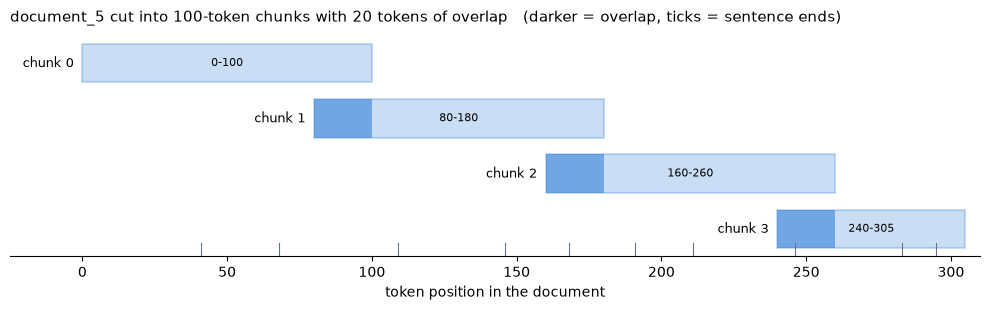

In [6]:
def sentence_ends(text):
    """Token offset of every sentence end (approximate: split on . ! ?)."""
    ends, pos = [], 0
    for s in re.split(r"(?<=[.!?])\s+", text):
        pos += len(enc.encode(s + " "))
        ends.append(pos)
    return ends

def draw_chunks(ax, text, chunks, title, highlight=None, color="#2a78d6"):
    n_tokens = len(enc.encode(text))
    for i, c in enumerate(chunks):
        y = -i
        ax.add_patch(Rectangle((c["start"], y - 0.35), c["end"] - c["start"], 0.7, facecolor=color, alpha=0.25, edgecolor=color, lw=1.5))
        if i > 0 and chunks[i - 1]["end"] > c["start"]:                 # the overlap with the previous chunk, darker
            ax.add_patch(Rectangle((c["start"], y - 0.35), chunks[i - 1]["end"] - c["start"], 0.7, facecolor=color, alpha=0.55, edgecolor="none"))
        ax.text(c["start"] - 3, y, f"chunk {i}", ha="right", va="center", fontsize=9)
        ax.text((c["start"] + c["end"]) / 2, y, f"{c['start']}-{c['end']}", ha="center", va="center", fontsize=8)
    if highlight:                                                        # a span of tokens we care about
        ax.axvspan(*highlight, color="#eda100", alpha=0.35, lw=0)
    for e in sentence_ends(text):
        ax.axvline(e, ymin=0, ymax=0.06, color="#64748B", lw=0.8)
    ax.set_xlim(-25, n_tokens + 5); ax.set_ylim(-len(chunks) + 0.5, 0.6)
    ax.set_yticks([]); ax.set_xlabel("token position in the document"); ax.set_title(title, loc="left", fontsize=11)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)

fig, ax = plt.subplots(figsize=(10, 3.2))
draw_chunks(ax, TEXT["document_5"], chunks, "document_5 cut into 100-token chunks with 20 tokens of overlap   (darker = overlap, ticks = sentence ends)")
plt.tight_layout(); plt.show()

Now the chunks go into the store. A second collection, `cyber_chunks`, in the same database, with the same embedding function. Each row gets an id like `document_5#2` and metadata that points back to the parent document and records the token span. That metadata is what lets you show "source: MFA article, paragraph 3" later, or filter to one document with `where`.

In [7]:
CHUNK_SIZE, OVERLAP = 100, 20

chunks_collection = chroma.get_or_create_collection(
    name="cyber_chunks", embedding_function=embed_local, configuration={"hnsw": {"space": "cosine"}}
)

if chunks_collection.count() == 0:
    ids, texts, metas = [], [], []
    for d in documents:
        for i, c in enumerate(chunk_by_tokens(d["text"], CHUNK_SIZE, OVERLAP)):
            ids.append(f"{d['id']}#{i}")
            texts.append(c["text"])
            metas.append({**d["metadata"], "doc_id": d["id"], "title": d["title"], "chunk": i, "start": c["start"], "end": c["end"]})
    chunks_collection.add(ids=ids, documents=texts, metadatas=metas)

print("rows in 'cyber_docs':  ", docs_collection.count())
print("rows in 'cyber_chunks':", chunks_collection.count())

row = chunks_collection.get(ids=["document_5#2"], include=["documents", "metadatas", "embeddings"])
print("\none chunk row:")
print("  id:      ", row["ids"][0])
print("  metadata:", row["metadatas"][0])
print("  text:    ", row["documents"][0][:100], "...")
print("  vector:  ", [round(float(x), 3) for x in row["embeddings"][0][:5]], "... (", len(row["embeddings"][0]), "numbers )")

rows in 'cyber_docs':   6
rows in 'cyber_chunks': 32

one chunk row:
  id:       document_5#2
  metadata: {'chunk': 2, 'start': 160, 'author': 'Security Team', 'doc_id': 'document_5', 'year': 2020, 'title': 'Multi-Factor Authentication', 'end': 260, 'difficulty': 'beginner', 'category': 'authentication'}
  text:      the login. MFA significantly reduces the risk of account takeovers, which are common in phishing at ...
  vector:   [-0.043, 0.007, 0.021, -0.027, 0.071] ... ( 384 numbers )


### 🔍 What just happened?

Six documents became 32 rows. From Chroma's point of view nothing special happened: it received 32 strings and embedded each one, exactly as it did with 6 strings in notebook 1. The chunking logic, the ids and the `doc_id` / `chunk` / `start` / `end` metadata are all ours. That is the general rule: **the vector database stores rows; what a row is, is your decision made before `add()`**.

The fixed window is deliberately dumb: it cuts mid-sentence. Production splitters are smarter about *where* they cut (sentence ends, paragraph breaks, Markdown headings) while keeping the same two knobs, size and overlap. LlamaIndex's `SentenceSplitter(chunk_size=..., chunk_overlap=...)` in module 3 is exactly that.

### 🎯 Mini-task

Write `chunk_by_sentences(text, max_tokens)`: split the text into sentences (the regex from `sentence_ends` works), then pack sentences into chunks that stay under `max_tokens`. No sentence should ever be cut. How many chunks does `document_5` give at 100 tokens, compared with 4 from the fixed window?

In [8]:
# YOUR CODE HERE

## 3. Chunks in the vector space

Slide 3 of the deck squashed the 384 dimensions to two to show that similar texts land close together. Let's draw the same picture with what we have now: six **document vectors** (big dots) and their 32 **chunk vectors** (small dots, connected to their parent). A question is drawn as a star and its best-matching chunk gets a ring.

Two dimensions keep only a fraction of the geometry, so read the picture for shapes, not for exact neighbours; the exact distances follow in the next cell.

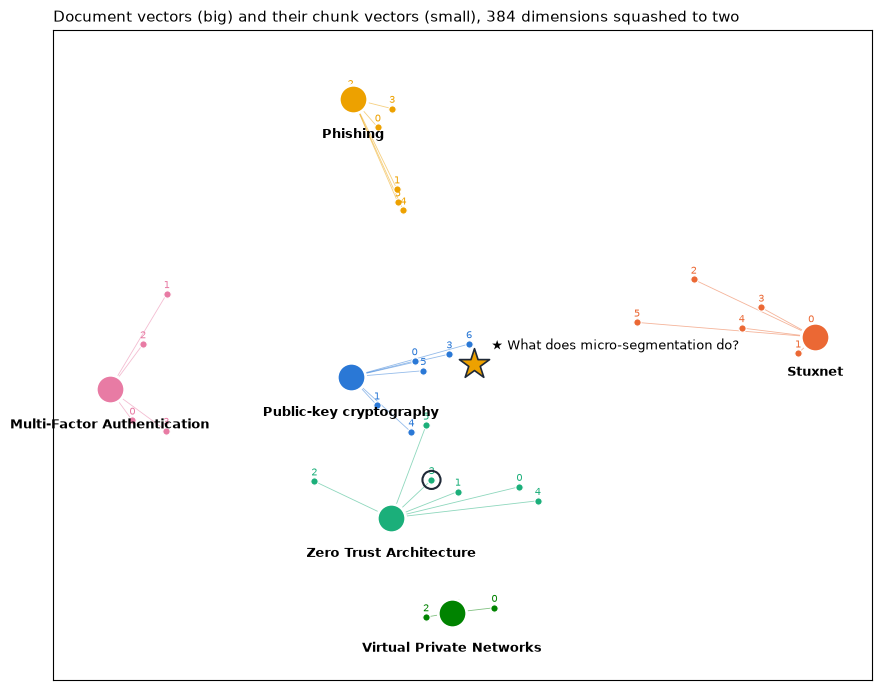

In [9]:
question = "What does micro-segmentation do?"

doc_rows = docs_collection.get(include=["embeddings"])
chunk_rows = chunks_collection.get(include=["embeddings", "metadatas"])
doc_vectors = np.array(doc_rows["embeddings"]); doc_ids = doc_rows["ids"]
chunk_vectors = np.array(chunk_rows["embeddings"]); chunk_ids = chunk_rows["ids"]
question_vector = np.array(embed_local([question]))

# PCA by hand: centre, SVD, keep the two directions with the most spread
all_vectors = np.vstack([doc_vectors, chunk_vectors])
centre = all_vectors.mean(axis=0)
_, _, Vt = np.linalg.svd(all_vectors - centre, full_matrices=False)
to_2d = lambda v: (v - centre) @ Vt[:2].T
d2, c2, q2 = to_2d(doc_vectors), to_2d(chunk_vectors), to_2d(question_vector)[0]

best_chunk = chunks_collection.query(query_texts=[question], n_results=1)["ids"][0][0]
COLORS = dict(zip(sorted(TEXT), ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]))

fig, ax = plt.subplots(figsize=(9, 7))
for j, doc_id in enumerate(doc_ids):
    colour = COLORS[doc_id]
    mine = [k for k, m in enumerate(chunk_rows["metadatas"]) if m["doc_id"] == doc_id]
    for k in mine:
        ax.plot([d2[j, 0], c2[k, 0]], [d2[j, 1], c2[k, 1]], color=colour, lw=0.6, alpha=0.5, zorder=1)
        ax.text(c2[k, 0], c2[k, 1] + 0.012, str(chunk_rows["metadatas"][k]["chunk"]), fontsize=7, ha="center", color=colour, zorder=4)
    ax.scatter(c2[mine, 0], c2[mine, 1], s=28, color=colour, edgecolor="white", lw=0.8, zorder=3)
    ax.scatter(d2[j, 0], d2[j, 1], s=420, color=colour, edgecolor="white", lw=2, zorder=5)
    ax.text(d2[j, 0], d2[j, 1] - 0.06, TITLE[doc_id], fontsize=9, ha="center", va="top", weight="bold", zorder=6)
k = chunk_ids.index(best_chunk)
ax.scatter(c2[k, 0], c2[k, 1], s=170, facecolor="none", edgecolor="#1F2937", lw=1.5, zorder=6)
ax.scatter(q2[0], q2[1], marker="*", s=520, color="#eda100", edgecolor="#1F2937", lw=1.2, zorder=7)
ax.text(q2[0] + 0.03, q2[1] + 0.03, f"★ {question}", fontsize=9, zorder=7)
ax.set_title("Document vectors (big) and their chunk vectors (small), 384 dimensions squashed to two", loc="left", fontsize=11)
ax.margins(x=0.08, y=0.12); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### 🔍 What just happened?

Look at where each big dot sits: **right on top of its chunk 0**, with the later chunks trailing away. That is section 1 drawn as a picture. The "document vector" is really the vector of the first 200 or so words; the chunks from the second half of the Zero Trust article (micro-segmentation, NIST, blast radius) are nowhere near "their own" document.

So chunk vectors are not just smaller copies of the document vector. They are more **detailed**: four chunk vectors of the MFA article describe four different things (factors, the bank example, the Microsoft statistic, SIM swapping), where the one document vector describes the article's opening. Let's put numbers on the picture: the distance from the question to each document vector and to each chunk of the winning document.

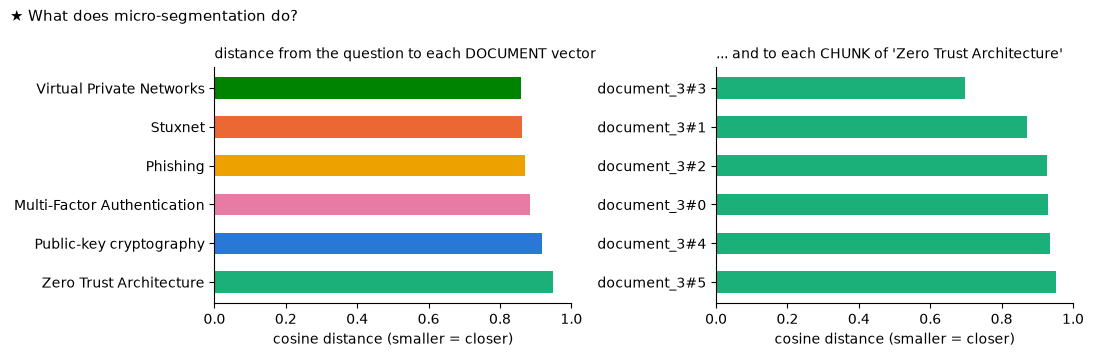

document level: document_6 wins at 0.858  ->  Virtual Private Networks
chunk level:    document_3#3 wins at 0.696  ->  Zero Trust Architecture, chunk 3


In [10]:
doc_hits = docs_collection.query(query_texts=[question], n_results=6, include=["distances"])
chunk_hits = chunks_collection.query(query_texts=[question], n_results=32, include=["distances", "metadatas"])

winner_doc = chunk_hits["metadatas"][0][0]["doc_id"]
doc_dist = dict(zip(doc_hits["ids"][0], doc_hits["distances"][0]))
chunk_dist = {i: dist for i, dist, m in zip(chunk_hits["ids"][0], chunk_hits["distances"][0], chunk_hits["metadatas"][0]) if m["doc_id"] == winner_doc}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
labels = [TITLE[i] for i in doc_dist]
ax1.barh(labels, list(doc_dist.values()), color=[COLORS[i] for i in doc_dist], height=0.55)
ax1.set_title("distance from the question to each DOCUMENT vector", loc="left", fontsize=10)
ax2.barh(list(chunk_dist), list(chunk_dist.values()), color=COLORS[winner_doc], height=0.55)
ax2.set_title(f"... and to each CHUNK of '{TITLE[winner_doc]}'", loc="left", fontsize=10)
for ax in (ax1, ax2):
    ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel("cosine distance (smaller = closer)")
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
plt.suptitle(f"★ {question}", x=0.01, ha="left", fontsize=11); plt.tight_layout(); plt.show()

print(f"document level: {doc_hits['ids'][0][0]} wins at {doc_hits['distances'][0][0]:.3f}  ->  {TITLE[doc_hits['ids'][0][0]]}")
print(f"chunk level:    {chunk_hits['ids'][0][0]} wins at {chunk_hits['distances'][0][0]:.3f}  ->  {TITLE[winner_doc]}, chunk {chunk_hits['metadatas'][0][0]['chunk']}")

### 🔍 What just happened?

At document level the question **lost**: the VPN article came first and the Zero Trust article, which contains the only sentence about micro-segmentation, came last of the six, at a distance where notebook 2's threshold of 0.7 would have thrown it out. The reason is in the picture: that sentence lives in the last third of the article, beyond what the model read. At chunk level the right paragraph wins outright.

Notice also the spread among the chunks of one document: chunk 3, the one with the micro-segmentation sentence, is the only one that comes close; the others, castles and moats included, are as far away as the document vector. One vector per document averages that spread away. Several vectors per document keep it, and that is the whole argument for chunking.

Let's run a dozen questions through both collections to see how general this is. Each question has a **gold phrase** we know is in the answer sentence, so we can check automatically whether the retrieved text contains it.

In [11]:
QUESTIONS = [   # (question, a phrase that must appear in the answering sentence, the document it lives in)
    ("Why is SMS a weak second factor?",                                  "SIM-swapping",      "document_5"),
    ("Which companies' stolen certificates did Stuxnet use to look legitimate?", "Realtek",   "document_2"),
    ("What is post-quantum cryptography for?",                            "post-quantum",      "document_1"),
    ("Which NIST publication describes Zero Trust?",                      "800-207",           "document_3"),
    ("What is whaling?",                                                  "whaling",           "document_4"),
    ("Which protocols do VPNs use to build the tunnel?",                  "WireGuard",         "document_6"),
    ("How did Stuxnet get into an isolated network?",                     "USB",               "document_2"),
    ("What are the three categories of authentication factors?",         "something you are", "document_5"),
    ("Which email protocols authenticate senders against phishing?",     "DMARC",             "document_4"),
    ("Who introduced public-key cryptography and when?",                  "1976",              "document_1"),
    ("What does micro-segmentation do?",                                  "micro-segmentation","document_3"),
    ("Why is public Wi-Fi risky without a VPN?",                          "packet sniffers",   "document_6"),
]

print(f"{'question':<58} {'document level':<22} {'chunk level'}")
for q, gold, gold_doc in QUESTIONS:
    d = docs_collection.query(query_texts=[q], n_results=1, include=["distances"])
    c = chunks_collection.query(query_texts=[q], n_results=1, include=["distances", "documents", "metadatas"])
    doc_ok = "✓" if d["ids"][0][0] == gold_doc else "✗"
    chunk_ok = "✓" if gold in c["documents"][0][0] else "✗"
    print(f"{q[:56]:<58} {doc_ok} {d['ids'][0][0]:<11} {d['distances'][0][0]:.3f}   {chunk_ok} {c['ids'][0][0]:<13} {c['distances'][0][0]:.3f}")

question                                                   document level         chunk level
Why is SMS a weak second factor?                           ✓ document_5  0.610   ✓ document_5#2  0.612
Which companies' stolen certificates did Stuxnet use to    ✓ document_2  0.466   ✓ document_2#4  0.325


What is post-quantum cryptography for?                     ✓ document_1  0.593   ✓ document_1#6  0.308
Which NIST publication describes Zero Trust?               ✓ document_3  0.460   ✓ document_3#4  0.321
What is whaling?                                           ✓ document_4  0.854   ✓ document_4#3  0.597


Which protocols do VPNs use to build the tunnel?           ✓ document_6  0.494   ✓ document_6#1  0.439
How did Stuxnet get into an isolated network?              ✓ document_2  0.359   ✓ document_2#1  0.345
What are the three categories of authentication factors?   ✓ document_5  0.385   ✓ document_5#0  0.375


Which email protocols authenticate senders against phish   ✓ document_4  0.540   ✓ document_4#5  0.355
Who introduced public-key cryptography and when?           ✓ document_1  0.414   ✓ document_1#0  0.296
What does micro-segmentation do?                           ✗ document_6  0.858   ✓ document_3#3  0.696


Why is public Wi-Fi risky without a VPN?                   ✓ document_6  0.350   ✓ document_6#1  0.435


### 🔍 What just happened?

Read the two distance columns side by side. For facts near the start of an article (Diffie and Hellman in 1976, the three factor categories) both levels are close and the numbers barely differ. For facts near the end (post-quantum cryptography, DMARC, the Stuxnet certificates) the chunk distance is far smaller, because the document vector never contained that part of the text. And in one case the document level picks the wrong article altogether.

### 🎯 Mini-task

Add three questions of your own to `QUESTIONS` and re-run the cell. Try one whose answer is in the first sentence of an article and one whose answer is in the last sentence. Does the pattern hold?

In [12]:
# YOUR CODE HERE

## 4. Tuning chunk size

If chunks are good, are smaller chunks better? Let's find out instead of guessing. We rebuild the store five times with chunk sizes from 32 to 512 tokens (no overlap yet) and, for each size, ask the twelve questions and check two things about the **top result**:

- does it contain the **gold phrase** (the retrieval found the right spot), and
- does it contain the **whole answer sentence** (the model will get a complete thought, not a fragment).

We also record what the size costs: how many rows the store has, and how many tokens the top three results would push into a prompt. Temporary collections live in an in-memory client so the persistent store stays clean.

In [13]:
def answer_sentence(doc_id, gold):
    for s in re.split(r"(?<=[.!?])\s+", TEXT[doc_id]):
        if gold in s:
            return s

GOLD = [(q, gold, gold_doc, answer_sentence(gold_doc, gold)) for q, gold, gold_doc in QUESTIONS]
scratch = chromadb.EphemeralClient()

def evaluate(chunk_size, overlap):
    """Chunk all six documents, index them, ask the twelve questions, return quality and cost numbers."""
    name = f"s{chunk_size}_o{overlap}"
    col = scratch.get_or_create_collection(name, embedding_function=embed_local, configuration={"hnsw": {"space": "cosine"}})
    ids, texts = [], []
    for d in documents:
        for i, c in enumerate(chunk_by_tokens(d["text"], chunk_size, overlap)):
            ids.append(f"{d['id']}#{i}"); texts.append(c["text"])
    col.add(ids=ids, documents=texts)

    phrase_hits = sentence_hits = 0; context_tokens = []; best_distances = []
    for q, gold, gold_doc, sentence in GOLD:
        r = col.query(query_texts=[q], n_results=3, include=["documents", "distances"])
        top = r["documents"][0][0]
        phrase_hits += gold in top
        sentence_hits += sentence in top
        best_distances.append(r["distances"][0][0])
        context_tokens.append(sum(len(enc.encode(t)) for t in r["documents"][0]))
    scratch.delete_collection(name)
    return {"chunk_size": chunk_size, "overlap": overlap, "rows": len(ids),
            "stored_tokens": sum(len(enc.encode(t)) for t in texts),
            "phrase_hits": phrase_hits, "sentence_hits": sentence_hits,
            "mean_best_distance": float(np.mean(best_distances)), "context_tokens": float(np.mean(context_tokens))}

SIZES = [32, 64, 128, 256, 512]
size_results = [evaluate(s, 0) for s in SIZES]

print(f"{'size':>5} {'rows':>5} {'phrase in top-1':>16} {'sentence intact':>16} {'best distance':>14} {'top-3 context':>14}")
for r in size_results:
    print(f"{r['chunk_size']:>5} {r['rows']:>5} {r['phrase_hits']:>13}/12 {r['sentence_hits']:>13}/12 {r['mean_best_distance']:>14.3f} {r['context_tokens']:>10.0f} tok")

 size  rows  phrase in top-1  sentence intact  best distance  top-3 context
   32    81             6/12             1/12          0.377         93 tok
   64    42             8/12             6/12          0.383        182 tok
  128    23             9/12             8/12          0.428        352 tok
  256    13            11/12            10/12          0.488        638 tok
  512     7            10/12            10/12          0.520       1148 tok


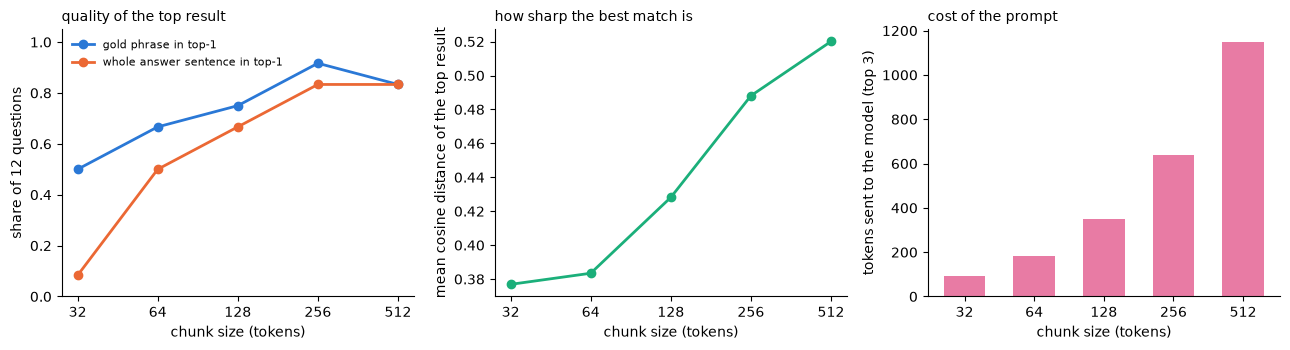

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 3.6))
sizes = [r["chunk_size"] for r in size_results]

ax1.plot(sizes, [r["phrase_hits"] / 12 for r in size_results], marker="o", color="#2a78d6", lw=2, label="gold phrase in top-1")
ax1.plot(sizes, [r["sentence_hits"] / 12 for r in size_results], marker="o", color="#eb6834", lw=2, label="whole answer sentence in top-1")
ax1.set_ylim(0, 1.05); ax1.set_ylabel("share of 12 questions"); ax1.set_title("quality of the top result", loc="left", fontsize=10); ax1.legend(frameon=False, fontsize=8)

ax2.plot(sizes, [r["mean_best_distance"] for r in size_results], marker="o", color="#1baf7a", lw=2)
ax2.set_ylabel("mean cosine distance of the top result"); ax2.set_title("how sharp the best match is", loc="left", fontsize=10)

ax3.bar([str(s) for s in sizes], [r["context_tokens"] for r in size_results], color="#e87ba4", width=0.6)
ax3.set_ylabel("tokens sent to the model (top 3)"); ax3.set_title("cost of the prompt", loc="left", fontsize=10)

for ax in (ax1, ax2):
    ax.set_xscale("log", base=2); ax.set_xticks(sizes); ax.set_xticklabels(sizes); ax.set_xlabel("chunk size (tokens)")
ax3.set_xlabel("chunk size (tokens)")
for ax in (ax1, ax2, ax3):
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

### 🔍 What just happened?

Three curves, three different stories, and they disagree:

- **Small chunks match sharply** (the best distance is lowest at 32 tokens) but deliver **fragments**: at 32 tokens the top result almost never contains the whole answer sentence, because most of our answer sentences are 25 to 45 tokens long.
- **Large chunks carry complete thoughts** but match **blurrily**: the best distance climbs steadily, and at 512 tokens we are nearly back to one chunk per article (7 rows for 6 articles), with the 256-word-piece ceiling from section 1 cutting the tails off again.
- **Cost grows linearly** with size: the same "top 3" costs more than ten times as many tokens at 512 as at 32.

There is no size that wins all three. The phrase hit rate peaks at 256 tokens here and the sentence curve flattens there too, which is why so many tutorials say "a few hundred tokens". But the right answer depends on your text (a legal clause is longer than a chat message), on your questions (fact lookups like small chunks, "summarise the policy" likes large ones) and on the ceiling of your embedding model. Measure, do not assume.

## 5. Tuning overlap

Now the second knob. Overlap exists for one reason: a boundary can fall in the middle of the sentence that answers the question. Section 3's very first question is a live example. At 128 tokens without overlap the answer sentence about SIM swapping is cut by the boundary at token 256; with 32 tokens of overlap one chunk holds it whole. The amber band marks the sentence.

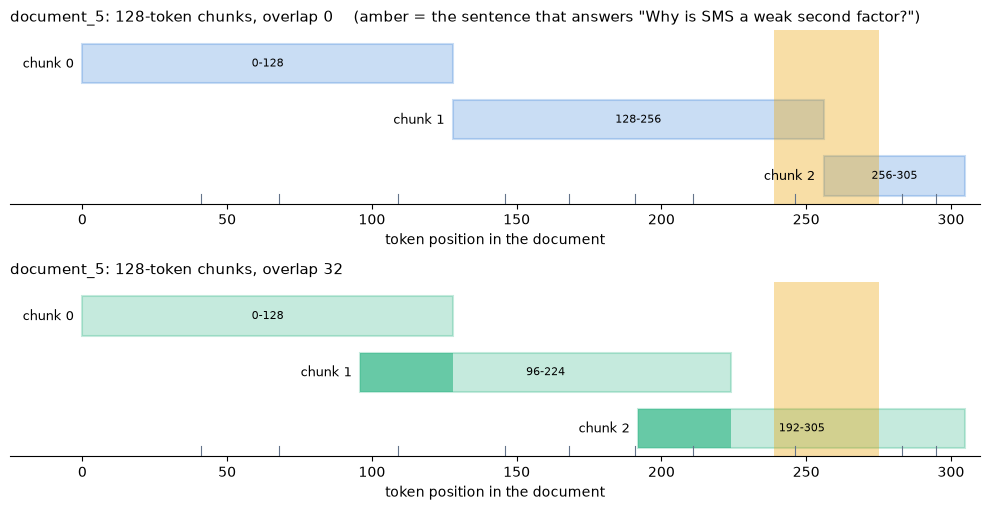

overlap  0: top chunk document_5#1 (distance 0.624), whole answer sentence inside: False
            ...ardware tokens like YubiKey, and biometric verification. While SMS-based MFA is better than nothing, it's vulnerable to SIM-swapping attacks

overlap 32: top chunk document_5#2 (distance 0.625), whole answer sentence inside: True
            ...secure alternatives. Organizations should implement MFA for all critical systems, especially email, VPN access, and administrative accounts.



In [15]:
q, gold, gold_doc, sentence = GOLD[0]
text = TEXT[gold_doc]
span_start = len(enc.encode(text[:text.index(sentence)]))
span = (span_start, span_start + len(enc.encode(sentence)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.2))
draw_chunks(ax1, text, chunk_by_tokens(text, 128, 0),  f"{gold_doc}: 128-token chunks, overlap 0    (amber = the sentence that answers \"{q}\")", highlight=span)
draw_chunks(ax2, text, chunk_by_tokens(text, 128, 32), f"{gold_doc}: 128-token chunks, overlap 32", highlight=span, color="#1baf7a")
plt.tight_layout(); plt.show()

for overlap in [0, 32]:
    col = scratch.get_or_create_collection("demo", embedding_function=embed_local, configuration={"hnsw": {"space": "cosine"}})
    pieces = chunk_by_tokens(text, 128, overlap)
    col.add(ids=[f"{gold_doc}#{i}" for i in range(len(pieces))], documents=[c["text"] for c in pieces])
    r = col.query(query_texts=[q], n_results=1, include=["documents", "distances"])
    scratch.delete_collection("demo")
    top = r["documents"][0][0]
    print(f"overlap {overlap:2d}: top chunk {r['ids'][0][0]} (distance {r['distances'][0][0]:.3f}), whole answer sentence inside: {sentence in top}")
    print(f"            ...{top[-140:]}\n")

Without overlap the best chunk ends with "vulnerable to SIM-swapping attacks": the *what* is there, the *how* (carriers moving the number to a new SIM card) sits in the next chunk, and the model would have to guess it. With overlap the sentence survives intact in chunk 2. So is more overlap always better? Same experiment as before, now over a grid of sizes **and** overlaps (0 %, 25 % and 50 % of the chunk size). Two heatmaps: what we gain, and what it costs in stored tokens.

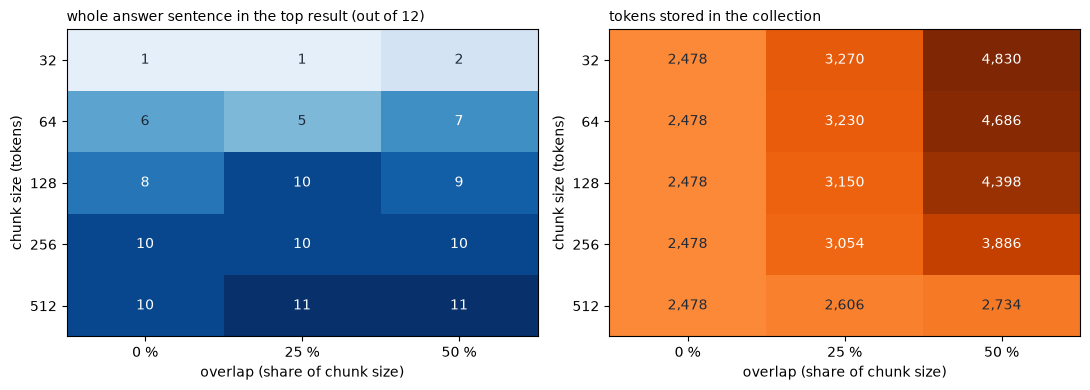

In [16]:
OVERLAPS = [0.0, 0.25, 0.5]
grid = [[evaluate(s, int(s * o)) for o in OVERLAPS] for s in SIZES]

sentence_grid = np.array([[r["sentence_hits"] for r in row] for row in grid])
stored_grid = np.array([[r["stored_tokens"] for r in row] for row in grid])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title, fmt, cmap in [(ax1, sentence_grid, "whole answer sentence in the top result (out of 12)", "{}", "Blues"),
                                   (ax2, stored_grid, "tokens stored in the collection", "{:,}", "Oranges")]:
    im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=0)
    for i in range(len(SIZES)):
        for j in range(len(OVERLAPS)):
            ax.text(j, i, fmt.format(data[i, j]), ha="center", va="center", fontsize=10, color="white" if data[i, j] > data.max() * 0.6 else "#1F2937")
    ax.set_xticks(range(len(OVERLAPS))); ax.set_xticklabels([f"{int(o*100)} %" for o in OVERLAPS]); ax.set_xlabel("overlap (share of chunk size)")
    ax.set_yticks(range(len(SIZES))); ax.set_yticklabels(SIZES); ax.set_ylabel("chunk size (tokens)")
    ax.set_title(title, loc="left", fontsize=10)
plt.tight_layout(); plt.show()

### 🔍 What just happened?

Overlap helps where boundaries hurt: at 128 tokens, 25 % overlap rescues two questions whose answer sentence had been cut. But look at the whole grid before you generalise. The gain is small and uneven (at 256 tokens it changes nothing, at 64 tokens 25 % is even slightly worse than 0 %), because moving the boundaries rescues some sentences and cuts others; overlap is insurance, not precision. And the price is real: at small chunk sizes 50 % overlap stores nearly twice the tokens and doubles the embedding bill (at 512 tokens it changes little, most articles are a single chunk anyway), and it returns near-duplicate chunks that you then have to de-duplicate before they reach the prompt.

The usual practice: 10 to 20 % overlap as insurance, sentence-aware splitting so that boundaries fall between sentences in the first place (your mini-task from section 2 removes most of the need for overlap), and a quick evaluation like this one on *your* documents and *your* questions before settling on numbers.

### 🎯 Mini-task

Change the questions. Replace `QUESTIONS` with five questions of your own (keep the format) and re-run sections 4 and 5. Do the best size and overlap move? They usually do, which is the real lesson: the knobs depend on the questions, not only on the documents.

In [17]:
# YOUR CODE HERE

## 6. Optional: RAG on chunks

The pipeline from notebook 2 does not change; only the collection does. Retrieval now returns paragraphs, and the source labels carry the document **and** the chunk, so a citation points at a paragraph rather than an article. Compare the size of the prompt with the document-level version for the same question. This section needs the OpenAI key.

In [18]:
from openai import OpenAI

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
MODEL = "gpt-5.6-luna"

def retrieve_chunks(question, max_results=3, max_distance=0.7):
    r = chunks_collection.query(query_texts=[question], n_results=max_results, include=["documents", "metadatas", "distances"])
    return [(f"{m['title']}, chunk {m['chunk']}", doc) for doc, m, dist in zip(r["documents"][0], r["metadatas"][0], r["distances"][0]) if dist <= max_distance]

def build_prompt(question, hits):
    sources = "\n\n".join(f"[{i}] ({label})\n{doc}" for i, (label, doc) in enumerate(hits, start=1))
    return ("Answer the question using ONLY the sources below. Cite the sources you use as [1], [2], ...\n"
            "If the sources do not contain the answer, say: I don't have enough information.\n\n"
            f"SOURCES:\n{sources}\n\nQUESTION: {question}")

question = "Why is SMS a weak second factor, and what should I use instead?"
chunk_hits = retrieve_chunks(question)
prompt = build_prompt(question, chunk_hits)

doc_level = docs_collection.query(query_texts=[question], n_results=3, include=["documents"])
print("document-level prompt would carry:", sum(len(enc.encode(d)) for d in doc_level["documents"][0]), "tokens of sources")
print("chunk-level prompt carries:       ", sum(len(enc.encode(d)) for _, d in chunk_hits), "tokens of sources")
print("sources:", [label for label, _ in chunk_hits], "\n")

answer = client.responses.create(model=MODEL, input=prompt).output_text
print(answer)

document-level prompt would carry: 1238 tokens of sources
chunk-level prompt carries:        265 tokens of sources
sources: ['Multi-Factor Authentication, chunk 2', 'Multi-Factor Authentication, chunk 3', 'Multi-Factor Authentication, chunk 0'] 



SMS is a weaker second factor because attackers can use SIM-swapping attacks to persuade mobile carriers to transfer your phone number to a new SIM card, allowing them to receive your verification codes [1][2].  

Use an authenticator app, such as Google Authenticator or Microsoft Authenticator, or a hardware security token such as a YubiKey instead; these are more secure alternatives [1][2].


### 🔍 What just happened?

Three paragraphs instead of three articles: a fraction of the tokens, and the citations name the exact paragraph. The answer quality did not suffer, because the paragraphs are the ones that actually talk about SMS codes and authenticator apps. In a store of thousands of long documents this is the difference between a prompt that fits and one that does not.

### 🎯 Your turn

1. Ask a question that needs two paragraphs from two different articles (phishing lures and MFA, for example). Does the chunk-level pipeline find both?
2. Overlapping chunks can come back as near-duplicates. Extend `retrieve_chunks` so that at most one chunk per document is kept (hint: the `doc_id` metadata), and see how the sources change.
3. Rebuild `cyber_chunks` with your `chunk_by_sentences` splitter from section 2 and compare the answers.

In [19]:
# YOUR CODE HERE

## What you take with you

- An embedding model has a **ceiling** and a **blur**: it reads only so many tokens, and it averages what it reads into one vector. One vector per long document loses the details.
- **Chunking happens before `add()`**, in your code or in a framework. The database stores rows; a chunk is a row with an id and metadata that points back to its document.
- Chunk vectors are **more detailed** than the document vector: each describes one passage, so specific questions find specific paragraphs, and the document vector turns out to be mostly the first chunk in disguise.
- **Chunk size** trades sharpness and cost against completeness; **overlap** is insurance against sentences cut by a boundary, paid for in stored tokens and duplicates. There is no universal setting; measure with your questions.
- The RAG pipeline is unchanged; only the rows got smaller and the citations more precise.

Next module: the same ideas in **Pinecone**, a managed vector database in the cloud. And in module 3 LlamaIndex's `SentenceSplitter` does the chunking for you, with the same two knobs you just tuned by hand.